<div align="center">

<h1> <b> OSCILADOR ARMÓNICO RELATIVISTA </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Vergara Restrepo Cristian <br>
Mendoza Montes Bernardo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  
</i></h3>
</div>

---


# Introducción

El oscilador armónico es uno de los modelos más relevantes de la física, ya que aparece en una amplia gama de sistemas y contextos, desde la mecánica clásica hasta la física cuántica. En su formulación estándar el modelo supone velocidades bajas frente a la velocidad de la luz, de modo que las ecuaciones de la mecánica newtoniana describen correctamente su dinámica.

Cuando las velocidades del sistema se aproximan a una fracción apreciable de la velocidad de la luz $c$, las predicciones de la mecánica clásica dejan de ser válidas y es necesario recurrir a la relatividad especial. En ese régimen incluso un oscilador armónico tan simple muestra un comportamiento no lineal, con cambios significativos en su dinámica temporal, su energía y su periodo de oscilación.

El oscilador armónico relativista resulta entonces un problema con interés tanto conceptual como pedagógico. Por un lado permite examinar de forma explícita los efectos dinámicos de la relatividad especial sobre un sistema familiar; por otro, como no admite soluciones analíticas cerradas en general, ofrece un contexto natural para aplicar métodos numéricos y realizar un análisis computacional detallado.

Este trabajo estudia el comportamiento de un oscilador armónico relativista en una dimensión, con énfasis en la implementación numérica de las ecuaciones de movimiento y en el análisis de los resultados obtenidos mediante simulación. Se comparan los regímenes relativista y clásico, cuantificando las desviaciones que los efectos relativistas introducen en las trayectorias, las velocidades, la energía y el periodo de oscilación.


# Marco teórico y formulación del problema

## Formulación clásica del oscilador armónico

En la mecánica clásica el oscilador armónico unidimensional se define mediante la fuerza restauradora lineal
$$
F = -m\omega^2 x,
$$
donde $m$ es la masa de la partícula, $\omega$ la frecuencia angular propia del sistema y $x(t)$ la posición. Al aplicar la segunda ley de Newton se obtiene la ecuación de movimiento
$$
m\ddot{x} = -m\omega^2 x,
$$
cuya solución es una oscilación sinusoidal de periodo constante
$$
T_0 = \frac{2\pi}{\omega},
$$
independiente de la amplitud inicial. Esta independencia del periodo respecto de la amplitud es precisamente uno de los rasgos distintivos del oscilador armónico clásico, y es lo que la relatividad especial modifica.

## Cantidad de movimiento relativista

En relatividad especial la relación entre fuerza y aceleración ya no conserva la estructura newtoniana. La dinámica se describe en su lugar a través de la cantidad de movimiento relativista
$$
p = \gamma m v,
$$
donde
$$
\gamma(v) = \frac{1}{\sqrt{1 - v^2/c^2}}
$$
es el factor de Lorentz y $v = \dot{x}$ es la velocidad de la partícula (Taylor y Wheeler, 1992; Resnick, 1968). La ecuación de movimiento toma entonces la forma
$$
\frac{dp}{dt} = \frac{d}{dt}(\gamma m v) = F.
$$

Si se conserva la misma fuerza restauradora que en el caso clásico,
$$
F = -m\omega^2 x,
$$
la ecuación de movimiento relativista queda
$$
\frac{d}{dt}(\gamma mv)=-m\omega^2 x.
$$

## Sistema de ecuaciones de primer orden

Para resolver el problema numéricamente conviene reescribir la ecuación anterior como un sistema de primer orden. Derivando explícitamente la cantidad de movimiento relativista se obtiene
$$
\frac{d}{dt}(\gamma v) = \gamma^3 \dot{v},
$$
de donde
$$
\dot{v} = -\frac{\omega^2 x}{\gamma^3(v)}.
$$

El sistema dinámico completo queda entonces
$$
\begin{cases}
\dot{x} = v, \\[6pt]
\dot{v} = -\dfrac{\omega^2x}{\gamma^3(v)}.
\end{cases}
$$

La dependencia de $\gamma$ con la velocidad hace que este sistema sea intrínsecamente no lineal, por lo que no admite en general soluciones analíticas cerradas y su estudio requiere métodos numéricos.

## Energía total del sistema relativista

La energía total del oscilador armónico relativista se define como la suma de la energía cinética relativista y la energía potencial de la fuerza restauradora:
$$
E = \gamma m c^2 + \frac{1}{2} m\omega^2 x^2.
$$

En ausencia de fuerzas disipativas esta cantidad se conserva a lo largo de la evolución temporal del sistema, y su conservación se usará más adelante como criterio para validar la precisión del método numérico.

## Límite clásico

En el límite $v \ll c$ el factor de Lorentz puede aproximarse como $\gamma \approx 1$, y el sistema relativista se reduce al oscilador armónico clásico:
$$
\dot{v} \approx -\omega^2 x.
$$
Este límite se usará como referencia para verificar que el modelo relativista se ha implementado correctamente.


# Metodología y método numérico

## Estrategia general de resolución

El sistema de ecuaciones diferenciales que describe al oscilador armónico relativista es no lineal y no admite soluciones analíticas cerradas, por lo que el problema se aborda mediante integración numérica directa en el tiempo. El objetivo de esta sección es describir con claridad y reproducibilidad el método empleado para obtener las trayectorias, velocidades y magnitudes físicas de interés.

La estrategia seguida consiste en:

1. Plantear el sistema de ecuaciones diferenciales de primer orden.
2. Elegir un método apropiado de integración numérica.
3. Establecer condiciones iniciales físicamente coherentes.
4. Definir criterios de validación y control del error numérico.
5. Repetir la simulación para distintos regímenes dinámicos.

## Sistema dinámico a integrar

El sistema a resolver es
$$
\begin{cases}
\dot{x}(t) = v(t), \\[6pt]
\dot{v}(t) = -\dfrac{\omega^2 x(t)}{\gamma^3(v)},
\end{cases}
\qquad
\gamma(v) = \dfrac{1}{\sqrt{1 - v^2/c^2}}.
$$
Este sistema describe por completo la evolución temporal del oscilador una vez fijadas las condiciones iniciales $x(0)$ y $v(0)$.

## Método de integración temporal

Se emplea el método de Runge-Kutta de cuarto orden (RK4) para la integración temporal (Press, Teukolsky, Vetterling y Flannery, 2007), un método estándar en la investigación numérica de sistemas dinámicos no lineales por su buen equilibrio entre costo computacional y precisión. En cada paso temporal $\Delta t$ el método evalúa el campo vectorial en cuatro puntos, lo que reduce de manera importante el error de truncamiento frente a métodos de menor orden. En este trabajo se usa un paso temporal constante, elegido de forma que garantice estabilidad numérica y una buena conservación de la energía.

## Condiciones iniciales y regímenes estudiados

Las simulaciones parten de la posición máxima del oscilador,
$$
x(0) = x_0,
$$
con velocidad inicial nula,
$$
v(0) = 0,
$$
de modo que la velocidad máxima se alcanza durante la evolución del sistema. Se consideran distintos valores de $x_0$ para explorar el régimen clásico ($v_{\max} \ll c$), el régimen relativista débil y el régimen relativista fuerte ($v_{\max}$ comparable con $c$), lo que permite analizar de forma sistemática cómo emergen los efectos relativistas al aumentar la amplitud inicial.

## Validación numérica

La calidad de la integración se evalúa con dos criterios complementarios. El primero es la conservación de la energía: la energía total relativista
$$
E(t) = \gamma(t) m c^2 + \frac{1}{2} m\omega^2 x^2(t)
$$
debe mantenerse aproximadamente constante durante toda la simulación, y la desviación respecto a su valor inicial se usa como medida directa del error numérico. El segundo es la convergencia temporal: los resultados no deberían cambiar de forma apreciable al refinar el paso de tiempo $\Delta t$, lo que confirma que la solución numérica se aproxima a la solución continua del sistema.


# Implementación numérica

El código se organiza en celdas independientes, cada una con una responsabilidad concreta: parámetros del sistema, funciones físicas, integrador temporal, solución clásica de referencia, estimación del periodo, simulación puntual, barrido en amplitud y visualización de resultados.

Para acelerar la integración se usa [Numba](https://numba.pydata.org/) (Lam, Pitrou y Seibert, 2015), un compilador *just-in-time* (JIT) que traduce funciones de Python a código máquina la primera vez que se ejecutan. Se aplican dos criterios para decidir cómo optimizar cada bucle:

- La integración temporal de un único caso (`integrar_relativista_core`) es una **recurrencia**: el estado en el paso $i+1$ depende del estado en el paso $i$. Un bucle de este tipo se compila con `@njit` pero se ejecuta de forma **secuencial**, sin paralelizar, porque paralelizarlo produciría resultados incorrectos (cada iteración necesita el resultado de la anterior).
- El barrido sobre distintas amplitudes iniciales $x_0$ (`sweep_amplitudes`) es en cambio un problema **"vergonzosamente paralelo"**: cada amplitud se integra de forma completamente independiente de las demás. Ese bucle sí se distribuye entre los núcleos del procesador usando `@njit(parallel=True)` junto con `prange` en lugar de `range`.

Como Numba no está garantizado en todos los entornos donde pueda ejecutarse este notebook, el import se protege con un bloque `try/except`: si Numba no está disponible, `njit` se reemplaza por un decorador que no hace nada y `prange` por el `range` estándar, de modo que el notebook sigue funcionando (más lento, pero con los mismos resultados numéricos).


In [ ]:
# =============================================================================
# Librerías y compilación opcional con Numba
# =============================================================================
# numpy y matplotlib son necesarios siempre. Numba es opcional: si no está
# instalado, se define un decorador "njit" que no hace nada (simplemente
# devuelve la función tal cual) y "prange" se convierte en el "range" normal
# de Python. Así el notebook corre igual en cualquier entorno, aunque sin
# la aceleración de la compilación JIT ni el paralelismo real.
import numpy as np
import matplotlib.pyplot as plt

try:
    from numba import njit, prange
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        # Permite usar tanto @njit como @njit(cache=True, parallel=True, ...)
        # sin que el código de más abajo tenga que preocuparse por si Numba
        # está instalado o no.
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def _decorador(func):
            return func

        return _decorador

    prange = range  # sin Numba, un bucle "paralelo" es simplemente secuencial

print(f"Numba disponible: {NUMBA_DISPONIBLE}")


Numba disponible: False


### Parámetros del sistema

Se trabaja en unidades naturales, fijando la velocidad de la luz $c=1$. Con esta elección las velocidades quedan expresadas directamente como fracciones de $c$ (por ejemplo, $v=0.5$ significa media velocidad de la luz), lo que simplifica la lectura de los resultados sin afectar la física del problema.


In [ ]:
# =============================================================================
# Parámetros físicos (unidades naturales: c = 1)
# =============================================================================
m = 1.0        # Masa de la partícula
omega = 1.0    # Frecuencia angular propia del oscilador, omega = sqrt(k/m)
c = 1.0        # Velocidad de la luz, fijada en 1 por conveniencia (unidades naturales)

# =============================================================================
# Parámetros numéricos
# =============================================================================
dt = 0.001        # Paso de tiempo de la integración
t_max = 200.0     # Tiempo total simulado
# Se guarda el número de pasos N para no recalcularlo cada vez y para poder
# pasarlo como argumento a las funciones compiladas con Numba, que necesitan
# conocer el tamaño de los arreglos de antemano.
N = int(t_max / dt) + 1
t = np.linspace(0.0, t_max, N)  # arreglo de instantes de tiempo de la simulación


### Funciones físicas del sistema

Estas dos funciones traducen directamente las ecuaciones del marco teórico: el factor de Lorentz $\gamma(v)$ y las derivadas $\dot{x}=v$, $\dot{v}=-\omega^2 x/\gamma^3(v)$. Se escriben en forma **escalar** (reciben y devuelven números, no arreglos de NumPy) porque Numba compila funciones escalares de forma mucho más eficiente que funciones que crean arreglos temporales dentro de un bucle; construir un `np.array` en cada llamada obliga a reservar memoria repetidamente y añade una sobrecarga que aquí se evita por completo.


In [ ]:
@njit(cache=True)
def derivatives_escalar(x, v, omega, c):
    '''Devuelve (dx/dt, dv/dt) para el oscilador armónico relativista.

    dx/dt = v es la definición de velocidad.
    dv/dt = -omega**2 * x / gamma(v)**3 es la ecuación de movimiento relativista
    obtenida en el marco teórico; la dependencia de gamma con v es lo que
    introduce la no linealidad del sistema.
    '''
    g = 1.0 / np.sqrt(1.0 - (v / c) ** 2)  # factor de Lorentz gamma(v)
    dxdt = v
    dvdt = -omega**2 * x / g**3
    return dxdt, dvdt


### Integrador temporal (RK4)

`rk4_paso_escalar` avanza el estado $(x, v)$ un único paso $\Delta t$ combinando cuatro evaluaciones de las derivadas, siguiendo la fórmula estándar del método de Runge-Kutta de cuarto orden.

`integrar_relativista_core` recorre todos los pasos de tiempo llamando repetidamente a `rk4_paso_escalar`. Este bucle **no se paraleliza**: el estado en el paso $i$ depende del estado en el paso $i-1$, de modo que los pasos deben calcularse estrictamente en orden. Se compila con `@njit` (sin `parallel=True` ni `prange`) para obtener la velocidad de código máquina conservando la ejecución secuencial que exige la recurrencia.


In [ ]:
@njit(cache=True)
def rk4_paso_escalar(x, v, dt, omega, c):
    '''Avanza el estado (x, v) un paso de tiempo dt usando RK4.'''
    k1x, k1v = derivatives_escalar(x, v, omega, c)
    k2x, k2v = derivatives_escalar(x + 0.5 * dt * k1x, v + 0.5 * dt * k1v, omega, c)
    k3x, k3v = derivatives_escalar(x + 0.5 * dt * k2x, v + 0.5 * dt * k2v, omega, c)
    k4x, k4v = derivatives_escalar(x + dt * k3x, v + dt * k3v, omega, c)
    x_nuevo = x + (dt / 6.0) * (k1x + 2.0 * k2x + 2.0 * k3x + k4x)
    v_nuevo = v + (dt / 6.0) * (k1v + 2.0 * k2v + 2.0 * k3v + k4v)
    return x_nuevo, v_nuevo


@njit(cache=True)
def integrar_relativista_core(x0, v0, dt, N, omega, c, m):
    '''Integra el sistema relativista para N pasos y devuelve (x, v, E).

    El bucle sobre i es secuencial a propósito: el paso i+1 se calcula a
    partir del paso i, así que no puede repartirse entre núcleos sin romper
    el orden de la recurrencia. Se reservan los arreglos con np.empty en
    lugar de ir haciendo crecer una lista, porque su tamaño N ya se conoce
    de antemano y así se evita la reasignación de memoria durante el bucle.
    '''
    x_arr = np.empty(N)
    v_arr = np.empty(N)
    x_arr[0] = x0
    v_arr[0] = v0
    for i in range(1, N):
        x_arr[i], v_arr[i] = rk4_paso_escalar(x_arr[i - 1], v_arr[i - 1], dt, omega, c)

    # La energía se calcula en un segundo bucle, independiente para cada
    # instante: no es una recurrencia, así que aquí sí sería lícito usar
    # prange, pero al ser un cálculo trivial (una sola división y una raíz
    # cuadrada por punto) el costo de repartirlo entre hilos superaría la
    # ganancia; se deja secuencial.
    E_arr = np.empty(N)
    for i in range(N):
        g = 1.0 / np.sqrt(1.0 - (v_arr[i] / c) ** 2)
        E_arr[i] = g * m * c**2 + 0.5 * m * omega**2 * x_arr[i] ** 2
    return x_arr, v_arr, E_arr


def integrate_relativistic(x0, v0, dt, t):
    '''Envoltorio con la interfaz integrate_relativistic(x0, v0, dt, t).

    Delega el trabajo pesado en la función compilada integrar_relativista_core,
    calculando de paso el número de pasos N a partir de la longitud de t.
    '''
    N_local = len(t)
    return integrar_relativista_core(x0, v0, dt, N_local, omega, c, m)


### Solución clásica de referencia

La solución analítica del oscilador armónico clásico sirve como referencia para comparar con el caso relativista. Al ser una expresión cerrada y ya vectorizada con NumPy, no se beneficia de Numba: NumPy ya delega estas operaciones en rutinas compiladas en C, por lo que compilar esta función no aportaría ninguna mejora de rendimiento.


In [ ]:
def classical_solution(x0, v0, t):
    '''Solución analítica x(t), v(t), E(t) del oscilador armónico clásico.

    Se usa como referencia para contrastar con la integración relativista,
    partiendo de las mismas condiciones iniciales (x0, v0).
    '''
    A = np.sqrt(x0**2 + (v0 / omega) ** 2)          # amplitud de la oscilación
    phi = np.arctan2(-v0 / omega, x0)                # fase inicial
    x = A * np.cos(omega * t + phi)
    v = -A * omega * np.sin(omega * t + phi)
    E = 0.5 * m * (v**2) + 0.5 * m * omega**2 * x**2  # energía total clásica (conservada)
    return x, v, E


### Estimación del periodo de oscilación

El periodo se estima detectando los máximos locales de $x(t)$ y promediando el intervalo de tiempo entre máximos consecutivos. Se descarta un tramo inicial (`t_skip`) para evitar transitorios numéricos, y se filtran máximos de baja amplitud (`min_height_frac`) para no confundir ruido numérico con un verdadero máximo. Al igual que el integrador, esta función se compila con `@njit`; como Numba no admite hacer crecer una lista de Python de forma eficiente dentro de una función compilada, se reserva de antemano un arreglo del tamaño máximo posible y se usa un contador (`count`) para saber cuántos máximos se encontraron realmente.


In [ ]:
@njit(cache=True)
def estimate_period_from_maxima_core(t, x, t_skip, min_height_frac):
    '''Estima (periodo_medio, desviacion_estandar) a partir de los máximos de x(t).'''
    N_local = len(x)

    # Umbral de altura mínima para descartar máximos espurios de baja
    # amplitud (ruido numérico), calculado como una fracción de la cresta
    # máxima absoluta de toda la señal.
    absmax = 0.0
    for i in range(N_local):
        ax = abs(x[i])
        if ax > absmax:
            absmax = ax
    min_height = absmax * min_height_frac

    maxima_times = np.empty(N_local)  # cota superior: a lo sumo N_local máximos
    count = 0
    for i in range(1, N_local - 1):
        # Un máximo local es un punto mayor que sus dos vecinos inmediatos;
        # además debe superar el umbral de altura y estar más allá del
        # tiempo de transitorio t_skip.
        if x[i - 1] < x[i] and x[i] > x[i + 1] and x[i] > min_height and t[i] > t_skip:
            maxima_times[count] = t[i]
            count += 1

    if count < 2:
        return np.nan, np.nan  # no hay suficientes máximos para estimar un periodo

    npts = count - 1
    periods = np.empty(npts)
    for k in range(npts):
        periods[k] = maxima_times[k + 1] - maxima_times[k]

    mean_p = 0.0
    for k in range(npts):
        mean_p += periods[k]
    mean_p /= npts

    var_p = 0.0
    for k in range(npts):
        d = periods[k] - mean_p
        var_p += d * d
    var_p /= npts  # desviación estándar poblacional, igual a np.std por defecto
    std_p = np.sqrt(var_p)

    return mean_p, std_p


def estimate_period_from_maxima(t, x, t_skip=5.0, min_height_frac=0.1):
    '''Envoltorio con la interfaz estimate_period_from_maxima(t, x, t_skip, min_height_frac).

    Convierte t y x a arreglos de float64 antes de llamar a la versión
    compilada, que exige tipos numéricos fijos para poder compilarse.
    '''
    return estimate_period_from_maxima_core(
        np.asarray(t, dtype=np.float64), np.asarray(x, dtype=np.float64), t_skip, min_height_frac
    )


### Simulación puntual ($x_0=1.5$)

Se reproduce el caso puntual usado como referencia en el resto del trabajo: una amplitud inicial $x_0=1.5$ partiendo del reposo. Se calculan la trayectoria relativista y la clásica, se estima el periodo de cada una y se verifica la conservación de la energía relativista.


In [ ]:
x0 = 1.5  # amplitud inicial
v0 = 0.0  # velocidad inicial (parte del reposo en el extremo)

x_rel, v_rel, E_rel = integrate_relativistic(x0, v0, dt, t)  # simulación relativista
x_cl, v_cl, E_cl = classical_solution(x0, v0, t)              # solución clásica

# Estimación del periodo para ambos casos, descartando el transitorio inicial.
T_rel, T_rel_std = estimate_period_from_maxima(t, x_rel, t_skip=5.0)
T_cl, T_cl_std = estimate_period_from_maxima(t, x_cl, t_skip=5.0)

print(f"Periodo estimado (relativista) = {T_rel:.6f} \u00B1 {T_rel_std:.6f} s")
print(f"Periodo te\u00f3rico (cl\u00e1sico)     = {2*np.pi/omega:.6f} s")
print(f"Max |v| (relativista) = {np.max(np.abs(v_rel)):.6f} c")
print(f"Conservaci\u00f3n energ\u00eda: deltaE_max = {np.max(np.abs(E_rel - E_rel[0])):.2e} unidades de E (m*c^2)")


Periodo estimado (relativista) = 8.578455 ± 0.000498 s
Periodo teórico (clásico)     = 6.283185 s
Max |v| (relativista) = 0.882353 c
Conservación energía: deltaE_max = 1.38e-13 unidades de E (m*c^2)


### Barrido en amplitud inicial (paralelizado)

Aquí sí se aplica paralelismo real: cada amplitud inicial $x_0$ del arreglo `amplitudes` da lugar a una simulación completa, y esas simulaciones son mutuamente independientes (ninguna necesita el resultado de otra). Este es exactamente el caso "vergonzosamente paralelo" descrito antes, así que `sweep_amplitudes` se compila con `@njit(parallel=True)` y reparte el bucle sobre las amplitudes con `prange` en lugar de `range`, permitiendo que Numba lo distribuya entre los núcleos disponibles del procesador. Dentro de cada iteración del `prange` la integración individual (`integrar_relativista_core`) sigue siendo secuencial, como corresponde a una recurrencia.


In [ ]:
@njit(parallel=True, cache=True)
def sweep_amplitudes(amplitudes, t, dt, omega, c, m, t_skip, min_height_frac):
    '''Integra el sistema para cada amplitud inicial, en paralelo.

    Cada iteración j del bucle prange es independiente de las demás: toma
    una amplitud, integra su propia trayectoria y calcula sus propias
    métricas (periodo, velocidad máxima, error de energía), sin compartir
    estado con las otras iteraciones. Por eso puede repartirse entre
    núcleos sin riesgo de condiciones de carrera.
    '''
    n_amp = len(amplitudes)
    N_local = len(t)
    periods_rel = np.empty(n_amp)
    periods_rel_std = np.empty(n_amp)
    vmax_rel = np.empty(n_amp)
    energy_err_rel = np.empty(n_amp)

    for j in prange(n_amp):
        a = amplitudes[j]
        x_r, v_r, E_r = integrar_relativista_core(a, 0.0, dt, N_local, omega, c, m)
        T_r, T_r_std = estimate_period_from_maxima_core(t, x_r, t_skip, min_height_frac)
        periods_rel[j] = T_r
        periods_rel_std[j] = T_r_std

        vmax_local = 0.0
        for i in range(N_local):
            av = abs(v_r[i])
            if av > vmax_local:
                vmax_local = av
        vmax_rel[j] = vmax_local

        e0 = E_r[0]
        err_local = 0.0
        for i in range(N_local):
            d = abs(E_r[i] - e0)
            if d > err_local:
                err_local = d
        energy_err_rel[j] = err_local

    return periods_rel, periods_rel_std, vmax_rel, energy_err_rel


amplitudes = np.linspace(0.1, 1.8, 12)  # rango de amplitudes iniciales a explorar
periods_rel, periods_rel_std, vmax_rel, energy_err_rel = sweep_amplitudes(
    amplitudes, t, dt, omega, c, m, 5.0, 0.1
)

T0 = 2 * np.pi / omega  # periodo clásico teórico, usado como referencia en los gráficos


# Visualización de resultados

Las cinco figuras siguientes ilustran, en este orden: la posición $x(t)$, la velocidad $v(t)$, la relación de periodos $T_{\rm rel}/T_0$, la velocidad máxima alcanzada y el error de conservación de la energía, todos en función de la amplitud inicial $x_0$ cuando corresponda.


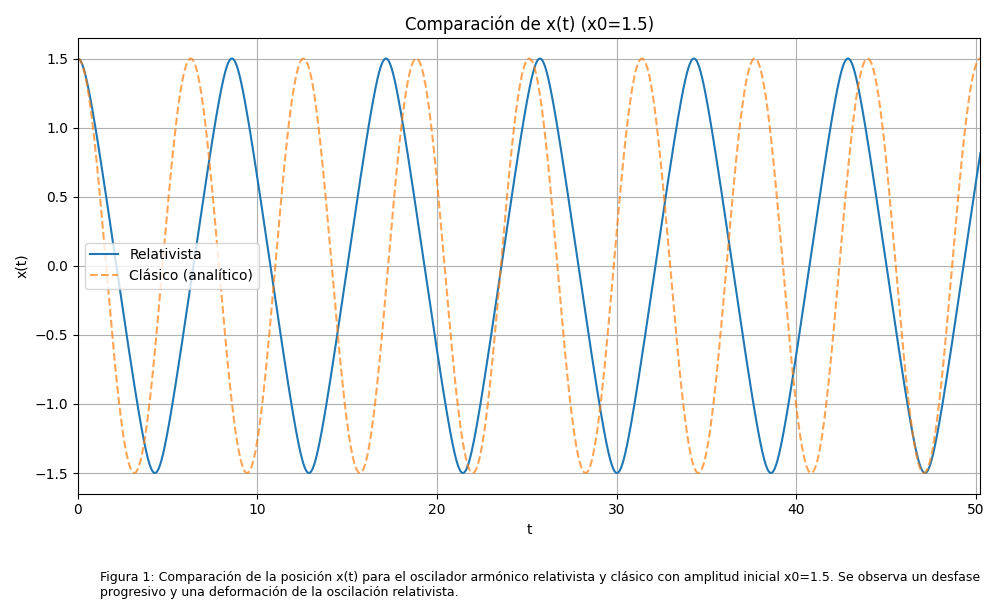

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, x_rel, label="Relativista")
plt.plot(t, x_cl, "--", label="Cl\u00e1sico (anal\u00edtico)", alpha=0.7)
plt.xlim(0, 8 * T0)  # limita el eje x a unas pocas oscilaciones para que se aprecie el desfase
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title(f"Comparaci\u00f3n de x(t) (x0={x0})")
plt.legend()
plt.grid()
plt.figtext(
    0.1, 0.01,
    "Figura 1: Comparaci\u00f3n de la posici\u00f3n x(t) para el oscilador arm\u00f3nico relativista y "
    "cl\u00e1sico con amplitud inicial x0=1.5. Se observa un desfase progresivo y una deformaci\u00f3n "
    "de la oscilaci\u00f3n relativista.",
    wrap=True, fontsize=9,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


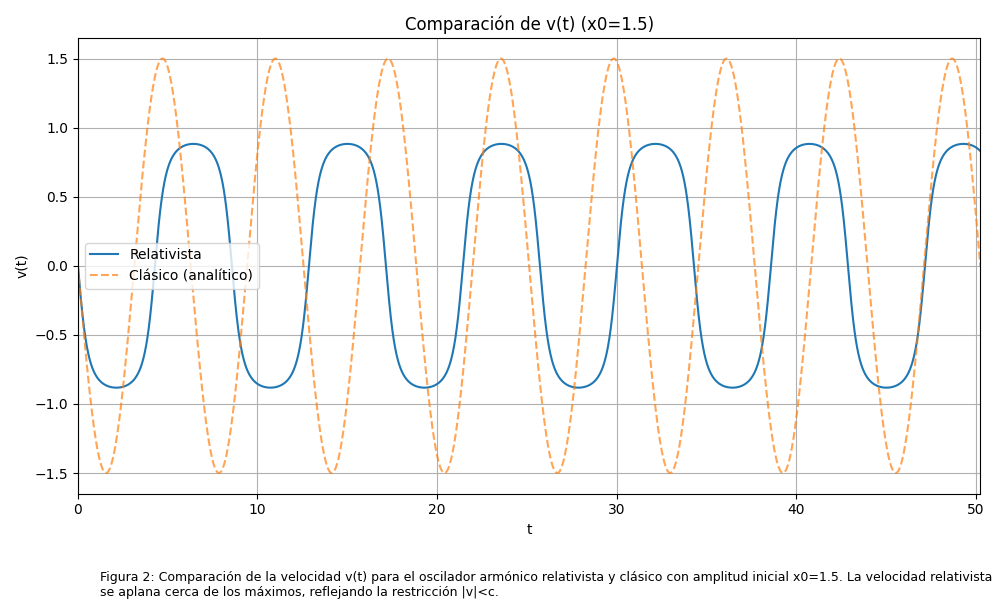

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(t, v_rel, label="Relativista")
plt.plot(t, v_cl, "--", label="Cl\u00e1sico (anal\u00edtico)", alpha=0.7)
plt.xlim(0, 8 * T0)
plt.xlabel("t")
plt.ylabel("v(t)")
plt.title(f"Comparaci\u00f3n de v(t) (x0={x0})")
plt.legend()
plt.grid()
plt.figtext(
    0.1, 0.01,
    "Figura 2: Comparaci\u00f3n de la velocidad v(t) para el oscilador arm\u00f3nico relativista y "
    "cl\u00e1sico con amplitud inicial x0=1.5. La velocidad relativista se aplana cerca de los "
    "m\u00e1ximos, reflejando la restricci\u00f3n |v|<c.",
    wrap=True, fontsize=9,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


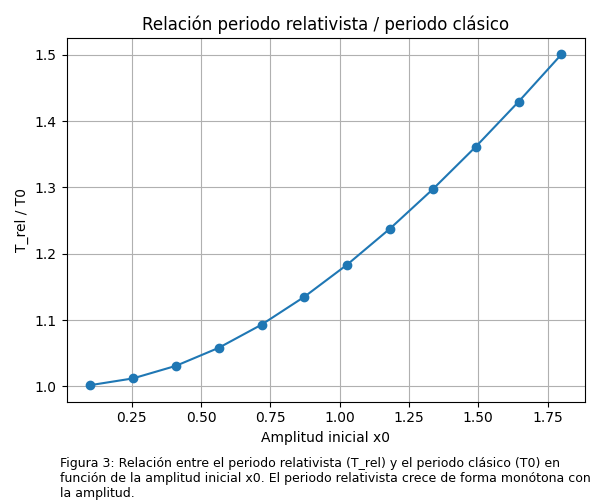

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(amplitudes, periods_rel / T0, "o-")
plt.xlabel("Amplitud inicial x0")
plt.ylabel("T_rel / T0")
plt.title("Relaci\u00f3n periodo relativista / periodo cl\u00e1sico")
plt.grid()
plt.figtext(
    0.1, 0.01,
    "Figura 3: Relaci\u00f3n entre el periodo relativista (T_rel) y el periodo cl\u00e1sico (T0) en "
    "funci\u00f3n de la amplitud inicial x0. El periodo relativista crece de forma mon\u00f3tona con "
    "la amplitud.",
    wrap=True, fontsize=9,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


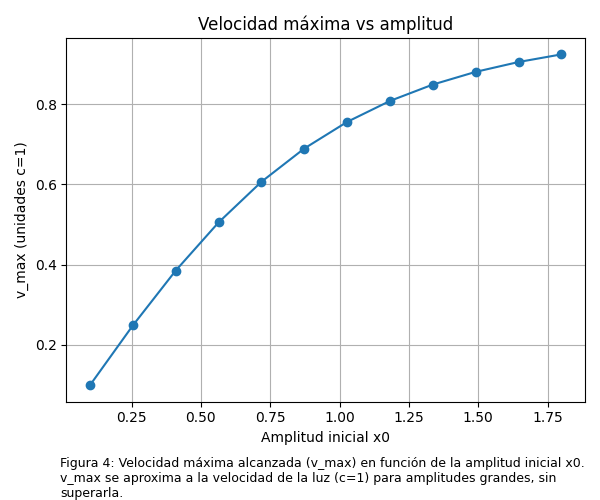

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(amplitudes, vmax_rel, "o-")
plt.xlabel("Amplitud inicial x0")
plt.ylabel("v_max (unidades c=1)")
plt.title("Velocidad m\u00e1xima vs amplitud")
plt.grid()
plt.figtext(
    0.1, 0.01,
    "Figura 4: Velocidad m\u00e1xima alcanzada (v_max) en funci\u00f3n de la amplitud inicial x0. "
    "v_max se aproxima a la velocidad de la luz (c=1) para amplitudes grandes, sin superarla.",
    wrap=True, fontsize=9,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


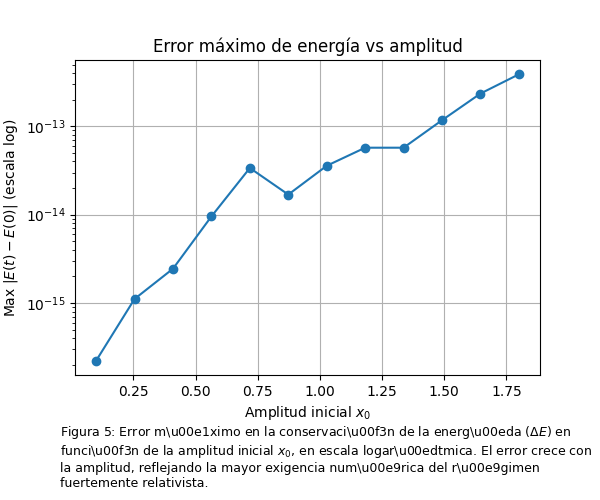

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.semilogy(amplitudes, energy_err_rel, "o-")
ax.set_xlabel("Amplitud inicial $x_0$")
ax.set_ylabel(r"Max $|E(t)-E(0)|$ (escala log)")
ax.set_title("Error m\u00e1ximo de energ\u00eda vs amplitud")
ax.grid()

fig_text_5 = (
    r"Figura 5: Error m\u00e1ximo en la conservaci\u00f3n de la energ\u00eda ($\Delta E$) en funci\u00f3n "
    r"de la amplitud inicial $x_0$, en escala logar\u00edtmica. El error crece con la amplitud, "
    r"reflejando la mayor exigencia num\u00e9rica del r\u00e9gimen fuertemente relativista."
)
fig.text(0.1, 0.02, fig_text_5, ha="left", va="bottom", wrap=True, fontsize=9)
fig.subplots_adjust(bottom=0.25)
plt.show()


### Datos de la simulación

Se guardan en un diccionario los resultados principales de la simulación puntual y del barrido en amplitud, por si se quieren reutilizar en un análisis posterior sin tener que repetir la integración.


In [ ]:
results = {
    "t": t,
    "x_rel": x_rel,
    "v_rel": v_rel,
    "E_rel": E_rel,
    "x_cl": x_cl,
    "v_cl": v_cl,
    "E_cl": E_cl,
    "amplitudes": amplitudes,
    "periods_rel": periods_rel,
    "periods_rel_std": periods_rel_std,
    "vmax_rel": vmax_rel,
    "energy_err_rel": energy_err_rel,
}


# Resultados

## Resumen numérico del caso $x_0=1.5$

Para una amplitud inicial $x_0=1.5$ la simulación relativista da un periodo $T_{\rm rel} = 8.578455 \pm 0.000498\ \mathrm{s}$, frente al periodo clásico teórico $T_0 = 6.283185\ \mathrm{s}$, es decir un cociente $T_{\rm rel}/T_0 \approx 1.36530$. La velocidad máxima alcanzada es $v_{\max} = 0.882353\,c$, y la desviación máxima de la energía respecto de su valor inicial es $\max |E(t)-E(0)| = 1.38\times 10^{-13}$, un valor consistente con el régimen relativista moderado-alto en el que se encuentra este caso.

## Observaciones sobre las figuras

La comparación temporal de la posición $x(t)$ entre el modelo relativista y el clásico (Fig. 1) muestra un desfase progresivo entre ambas soluciones, junto con una deformación en los extremos de la oscilación relativista: aunque parten de la misma amplitud inicial, el sistema relativista tarda más en completar cada ciclo.

La comparación de las velocidades $v(t)$ (Fig. 2) muestra que la solución relativista se aplana cerca de sus máximos, reflejando la restricción $|v|<c$, mientras que la solución clásica sigue creciendo sin ese límite y alcanza valores no físicos dentro del marco relativista.

El barrido en amplitud inicial $x_0$ confirma estas tendencias de forma sistemática: la relación de periodos $T_{\rm rel}/T_0$ (Fig. 3) crece de manera monótona con $x_0$; la velocidad máxima $v_{\max}$ (Fig. 4) aumenta con la amplitud y se aproxima gradualmente al valor límite $c$ sin sobrepasarlo; y el error máximo en la conservación de la energía (Fig. 5) también crece con $x_0$, lo que refleja una mayor exigencia numérica a medida que el sistema entra en un régimen fuertemente relativista.

## Interpretación cuantitativa

El aumento de un $36.5\%$ aproximadamente en el periodo para $x_0=1.5$ respecto de $T_0$ es coherente con la ralentización dinámica que introduce el factor $\gamma(v)$ en la ecuación de movimiento: a medida que la velocidad se acerca a $c$ se necesita cada vez más energía para seguir acelerando la partícula, lo que prolonga el tiempo de cada oscilación. La velocidad máxima observada, $v_{\max}\approx 0.8824\,c$, sitúa claramente este caso fuera del régimen clásico y explica la diferencia sustancial entre ambas soluciones en las Figuras 1 y 2.

La desviación máxima en la energía, del orden de $10^{-13}$, es extremadamente pequeña y compatible con la precisión esperada del método RK4 con paso temporal $dt=10^{-3}$. Aun así, su crecimiento sistemático con la amplitud inicial (Fig. 5) indica que las simulaciones más fuertemente relativistas exigen un control de error más cuidadoso, por ejemplo mediante un paso de tiempo adaptativo.


# Discusión y conclusiones

## Discusión

Los resultados muestran que incluir la relatividad especial altera de forma significativa el comportamiento de un sistema aparentemente sencillo como el oscilador armónico. Para amplitudes pequeñas, donde la velocidad máxima es mucho menor que la velocidad de la luz, el sistema se comporta con gran fidelidad como el oscilador armónico clásico: el periodo es prácticamente constante e independiente de la amplitud, y las trayectorias $x(t)$ y $v(t)$ coinciden con las soluciones analíticas conocidas.

A medida que aumenta la amplitud inicial, y con ella la velocidad máxima alcanzada, aparecen efectos relativistas que modifican de forma apreciable la dinámica. El incremento sistemático del periodo observado en la simulación (Fig. 3) se debe a la dependencia no lineal del factor de Lorentz $\gamma(v)$ en la ecuación de movimiento: cuando la velocidad se acerca a $c$, una fracción cada vez mayor de la energía del sistema se destina a aumentar la energía relativista de la partícula en lugar de su aceleración, lo que hace más lenta la oscilación.

Esta diferencia se aprecia con claridad al comparar las soluciones clásica y relativista para la misma amplitud inicial (Fig. 1): la solución clásica mantiene una frecuencia invariable, mientras que la relativista acumula un desfase temporal creciente y una deformación notoria de la forma de la oscilación. El efecto es aún más visible en la velocidad $v(t)$ (Fig. 2), donde el modelo relativista muestra una saturación gradual de los máximos frente al crecimiento sin límite que predice el modelo clásico.

Desde el punto de vista numérico, la conservación de la energía total relativista es el criterio esencial de validación empleado en este trabajo. La precisión del integrador de Runge-Kutta de cuarto orden con paso temporal constante resulta adecuada para un análisis cualitativo y semicuantitativo del sistema, como muestran los errores observados, del orden de $10^{-13}$ en amplitudes intermedias y algo mayores en amplitudes grandes (Fig. 5). Sin embargo, el crecimiento del error con la amplitud revela que las no linealidades del régimen fuertemente relativista exigen mayor potencia de cálculo o un paso de tiempo adaptativo si se busca mantener la misma precisión relativa.

## Conclusiones

A partir de la investigación numérica del oscilador armónico relativista unidimensional mediante un integrador RK4, y de la comparación sistemática con sus propiedades dinámicas clásicas, se pueden extraer las siguientes conclusiones:

1. A diferencia del oscilador armónico clásico, cuyo periodo es constante, el oscilador armónico relativista presenta un periodo que depende de la amplitud inicial.
2. El periodo relativista aumenta de forma monótona con la amplitud, con incrementos que llegan a ser considerables en el régimen fuertemente relativista.
3. La velocidad máxima del oscilador se aproxima asintóticamente a $c$ conforme crece la amplitud inicial, sin superarla en ningún momento, en concordancia con el postulado relativista de velocidad límite.
4. La conservación de la energía total relativista, con errores del orden de $10^{-13}$ a $10^{-11}$ según la amplitud, confirma que el integrador RK4 con el paso temporal empleado ofrece una precisión adecuada para el análisis realizado, aunque conviene refinarlo si se estudian regímenes aún más extremos.


# Referencias

## Fuentes académicas primarias

Taylor, E. F., & Wheeler, J. A. (1992). *Spacetime physics: Introduction to special relativity* (2nd ed.). W. H. Freeman and Company.

Resnick, R. (1968). *Introduction to special relativity*. John Wiley & Sons.

Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P. (2007). *Numerical recipes: The art of scientific computing* (3rd ed.). Cambridge University Press.

Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15, artículo 7). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

## Recursos complementarios

Tegmark, M. (2006). *8.033 Relativity* [Notas y materiales del curso]. MIT OpenCourseWare. https://ocw.mit.edu/courses/8-033-relativity-fall-2006/

PBS Space Time. (2015, 6 de octubre). *The speed of light is not about light* [Video]. PBS. https://www.pbs.org/video/pbs-space-time-speed-light-not-about-light
